<a href="https://colab.research.google.com/github/bhavya-sree-13/fds-lab-data-wrangling/blob/main/fds_lab_data_wrangling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DATASET LOADED
Dataset shape: (500, 9)

First 5 rows:
   PassengerId  Pclass     Sex   Age  SibSp  Parch   Fare Embarked  Survived
0            1       3    male  24.2      0      0  17.71        Q         0
1            2       3  female  32.6      0      2  46.90        S         0
2            3       3  female  25.0      0      0  43.13        S         1
3            4       3  female  29.7      0      0  20.67        S         0
4            5       3  female  45.1      0      0  23.34        S         0

Last 5 rows:
     PassengerId  Pclass     Sex   Age  SibSp  Parch   Fare Embarked  Survived
495          496       1    male  13.6      0      0  52.90        S         1
496          497       3  female   NaN      0      0  17.75        C         1
497          498       2    male  10.0      0      1  49.56        S         0
498          499       1    male  43.9      3      2  57.95        S         0
499          500       3    male  15.3      4      0   8.48        S    

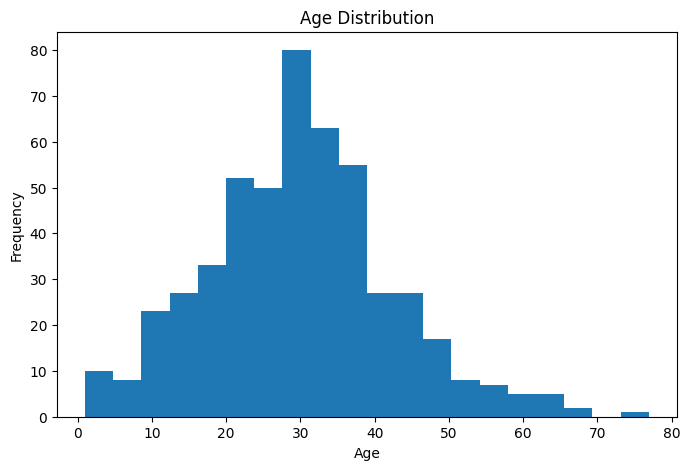

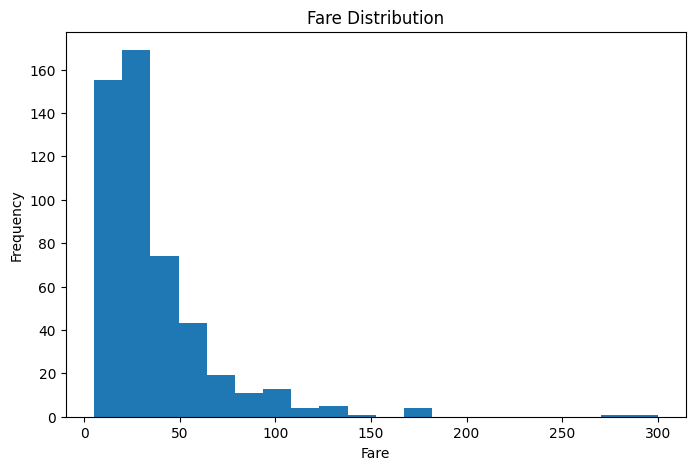

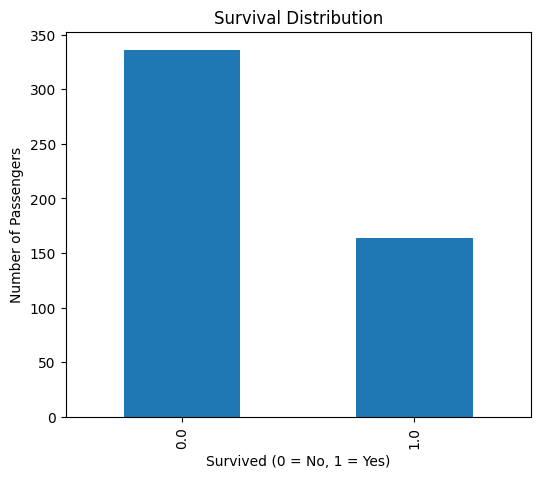

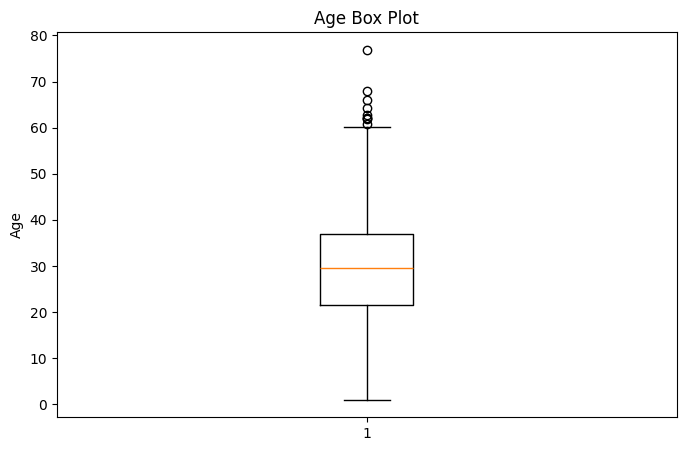

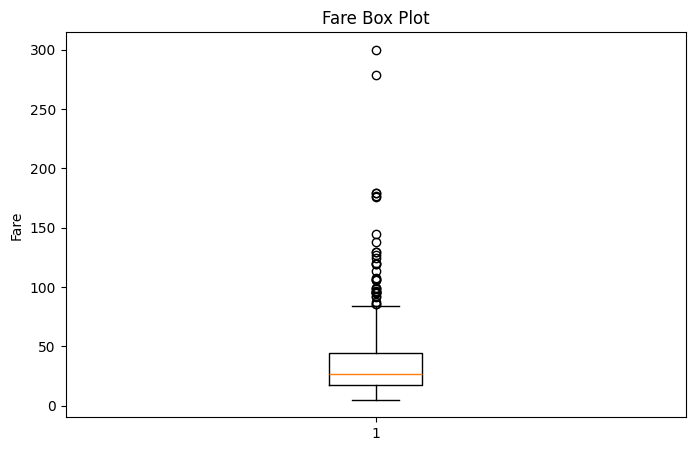


24. FINAL DATA TYPES
passenger_id                int64
pclass                      int64
sex                string[python]
age                       float64
sibsp                       int64
parch                       int64
fare                      float64
embarked           string[python]
survived                    int64
family_size                 int64
is_alone                    int64
fare_per_person           float64
age_group                category
family_category          category
fare_category            category
dtype: object

25. FINAL MISSING VALUE CHECK
passenger_id       0
pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           0
survived           0
family_size        0
is_alone           0
fare_per_person    0
age_group          0
family_category    0
fare_category      0
dtype: int64

SUCCESS: No missing values remain.

26. FINAL DUPLICATE CHECK
Duplicate rows: 0
SUCCESS: No du

In [ ]:
# ================================================================
# TITANIC DATASET - COMPLETE DATA WRANGLING & DATA QUALITY
# ================================================================

# ================================================================
# 0. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


# ================================================================
# 1. LOAD DATASET
# ================================================================

INPUT_FILE = "titanic.csv.csv"

df = pd.read_csv(INPUT_FILE)

print("=" * 80)
print("1. DATASET LOADED")
print("=" * 80)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())


# ================================================================
# 2. CREATE A COPY OF RAW DATA
# ================================================================

raw_df = df.copy()

print("\nRaw dataset stored for before/after comparison.")


# ================================================================
# 3. INITIAL DATA PROFILING
# ================================================================

print("\n" + "=" * 80)
print("2. INITIAL DATA PROFILING")
print("=" * 80)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe(include="all"))

print("\nMissing values:")
print(df.isnull().sum())

print("\nMissing-value percentage:")
print(
    (df.isnull().sum() / len(df) * 100)
    .round(2)
)

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ================================================================
# 4. STANDARDIZE COLUMN NAMES
# ================================================================

print("\n" + "=" * 80)
print("3. STANDARDIZING COLUMN NAMES")
print("=" * 80)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Handle common Titanic column name
df = df.rename(
    columns={
        "passengerid": "passenger_id"
    }
)

print("Standardized columns:")
print(df.columns.tolist())


# ================================================================
# 5. CHECK COLUMN NAME DUPLICATES
# ================================================================

duplicate_columns = df.columns[
    df.columns.duplicated()
].tolist()

print("\nDuplicate column names:")

if len(duplicate_columns) == 0:
    print("None")
else:
    print(duplicate_columns)


# ================================================================
# 6. CLEAN STRING/CATEGORICAL COLUMNS
# ================================================================

print("\n" + "=" * 80)
print("4. CLEANING TEXT COLUMNS")
print("=" * 80)

text_columns = [
    "sex",
    "embarked"
]

for col in text_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        print(f"{col} cleaned.")


# ================================================================
# 7. CHECK CATEGORICAL VALUES
# ================================================================

print("\n" + "=" * 80)
print("5. CATEGORICAL VALUE CHECK")
print("=" * 80)

for col in text_columns:

    if col in df.columns:

        print(f"\nUnique values in {col}:")
        print(df[col].value_counts(dropna=False))


# ================================================================
# 8. REMOVE EXACT DUPLICATE ROWS
# ================================================================

print("\n" + "=" * 80)
print("6. DUPLICATE ROW HANDLING")
print("=" * 80)

duplicates_before = df.duplicated().sum()

print("Duplicate rows before:", duplicates_before)

df = df.drop_duplicates().copy()

duplicates_after = df.duplicated().sum()

print("Duplicate rows after:", duplicates_after)


# ================================================================
# 9. CONVERT NUMERIC COLUMNS
# ================================================================

print("\n" + "=" * 80)
print("7. NUMERIC DATA TYPE CONVERSION")
print("=" * 80)

numeric_columns = [
    "passenger_id",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "survived"
]

for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        print(f"{col} converted to numeric.")


# ================================================================
# 10. IDENTIFY INVALID VALUES
# ================================================================

print("\n" + "=" * 80)
print("8. INVALID VALUE CHECK")
print("=" * 80)

# Age
invalid_age = (
    (~df["age"].between(0, 100)) &
    df["age"].notna()
).sum()

print("Invalid age values:", invalid_age)

# Fare
invalid_fare = (
    (df["fare"] < 0) &
    df["fare"].notna()
).sum()

print("Invalid fare values:", invalid_fare)

# Passenger class
invalid_pclass = (
    (~df["pclass"].isin([1, 2, 3])) &
    df["pclass"].notna()
).sum()

print("Invalid passenger class values:", invalid_pclass)

# Survived
invalid_survived = (
    (~df["survived"].isin([0, 1])) &
    df["survived"].notna()
).sum()

print("Invalid survived values:", invalid_survived)

# SibSp
invalid_sibsp = (
    (df["sibsp"] < 0) &
    df["sibsp"].notna()
).sum()

print("Invalid SibSp values:", invalid_sibsp)

# Parch
invalid_parch = (
    (df["parch"] < 0) &
    df["parch"].notna()
).sum()

print("Invalid Parch values:", invalid_parch)


# ================================================================
# 11. REPLACE INVALID VALUES WITH NaN
# ================================================================

print("\n" + "=" * 80)
print("9. REPLACING INVALID VALUES")
print("=" * 80)

df.loc[
    ~df["age"].between(0, 100),
    "age"
] = np.nan

df.loc[
    df["fare"] < 0,
    "fare"
] = np.nan

df.loc[
    ~df["pclass"].isin([1, 2, 3]),
    "pclass"
] = np.nan

df.loc[
    ~df["survived"].isin([0, 1]),
    "survived"
] = np.nan

df.loc[
    df["sibsp"] < 0,
    "sibsp"
] = np.nan

df.loc[
    df["parch"] < 0,
    "parch"
] = np.nan

print("Invalid values converted to missing values.")


# ================================================================
# 12. MISSING VALUE ANALYSIS
# ================================================================

print("\n" + "=" * 80)
print("10. MISSING VALUE ANALYSIS")
print("=" * 80)

missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum() /
        len(df) * 100
    ).round(2)
})

print(missing_report)


# ================================================================
# 13. HANDLE MISSING CATEGORICAL VALUES
# ================================================================

print("\n" + "=" * 80)
print("11. CATEGORICAL MISSING VALUE IMPUTATION")
print("=" * 80)

# Embarked → mode

if df["embarked"].isnull().any():

    embarked_mode = df["embarked"].mode()[0]

    print(
        "Embarked missing values:",
        df["embarked"].isnull().sum()
    )

    print(
        "Using mode:",
        embarked_mode
    )

    df["embarked"] = df["embarked"].fillna(
        embarked_mode
    )


# Sex → mode, if required

if df["sex"].isnull().any():

    sex_mode = df["sex"].mode()[0]

    print(
        "Sex missing values:",
        df["sex"].isnull().sum()
    )

    df["sex"] = df["sex"].fillna(
        sex_mode
    )


# ================================================================
# 14. HANDLE MISSING NUMERIC VALUES
# ================================================================

print("\n" + "=" * 80)
print("12. NUMERIC MISSING VALUE IMPUTATION")
print("=" * 80)


# ------------------------------------------------
# AGE
# ------------------------------------------------

age_missing_before = df["age"].isnull().sum()

print(
    "Age missing before:",
    age_missing_before
)

# Median based on Sex + Pclass
age_group_median = (
    df.groupby(
        ["sex", "pclass"]
    )["age"]
    .transform("median")
)

df["age"] = df["age"].fillna(
    age_group_median
)

# Overall median fallback
df["age"] = df["age"].fillna(
    df["age"].median()
)

print(
    "Age missing after:",
    df["age"].isnull().sum()
)


# ------------------------------------------------
# FARE
# ------------------------------------------------

fare_missing_before = df["fare"].isnull().sum()

print(
    "\nFare missing before:",
    fare_missing_before
)

# Median based on Pclass
fare_group_median = (
    df.groupby("pclass")["fare"]
    .transform("median")
)

df["fare"] = df["fare"].fillna(
    fare_group_median
)

# Overall median fallback
df["fare"] = df["fare"].fillna(
    df["fare"].median()
)

print(
    "Fare missing after:",
    df["fare"].isnull().sum()
)


# ------------------------------------------------
# PCLASS
# ------------------------------------------------

if df["pclass"].isnull().any():

    df["pclass"] = df["pclass"].fillna(
        df["pclass"].mode()[0]
    )


# ------------------------------------------------
# SIBSP
# ------------------------------------------------

if df["sibsp"].isnull().any():

    df["sibsp"] = df["sibsp"].fillna(
        df["sibsp"].median()
    )


# ------------------------------------------------
# PARCH
# ------------------------------------------------

if df["parch"].isnull().any():

    df["parch"] = df["parch"].fillna(
        df["parch"].median()
    )


# ------------------------------------------------
# SURVIVED
# ------------------------------------------------

if df["survived"].isnull().any():

    df["survived"] = df["survived"].fillna(
        df["survived"].median()
    )


# ================================================================
# 15. CHECK UNIQUE VALUES / CARDINALITY
# ================================================================

print("\n" + "=" * 80)
print("13. UNIQUE VALUE / CARDINALITY CHECK")
print("=" * 80)

for col in df.columns:

    print(
        f"{col}: {df[col].nunique()} unique values"
    )


# ================================================================
# 16. VALIDATE CATEGORICAL VALUES
# ================================================================

print("\n" + "=" * 80)
print("14. CATEGORICAL VALIDATION")
print("=" * 80)

print("\nSex values:")
print(df["sex"].value_counts())

print("\nEmbarked values:")
print(df["embarked"].value_counts())

print("\nPclass values:")
print(df["pclass"].value_counts().sort_index())

print("\nSurvived values:")
print(df["survived"].value_counts().sort_index())


# ================================================================
# 17. RANGE CHECK
# ================================================================

print("\n" + "=" * 80)
print("15. RANGE CHECK")
print("=" * 80)

print("\nAge range:")
print(df["age"].min(), "to", df["age"].max())

print("\nFare range:")
print(df["fare"].min(), "to", df["fare"].max())

print("\nFamily variables:")
print("SibSp:", df["sibsp"].min(), "to", df["sibsp"].max())
print("Parch:", df["parch"].min(), "to", df["parch"].max())

print("\nPclass:")
print(df["pclass"].unique())

print("\nSurvived:")
print(df["survived"].unique())


# ================================================================
# 18. CONSISTENCY CHECKS
# ================================================================

print("\n" + "=" * 80)
print("16. CONSISTENCY CHECKS")
print("=" * 80)

# SibSp and Parch cannot be negative
print(
    "Negative SibSp:",
    (df["sibsp"] < 0).sum()
)

print(
    "Negative Parch:",
    (df["parch"] < 0).sum()
)

# Survived must be 0 or 1
print(
    "Invalid Survived:",
    (~df["survived"].isin([0, 1])).sum()
)

# Pclass must be 1,2,3
print(
    "Invalid Pclass:",
    (~df["pclass"].isin([1, 2, 3])).sum()
)


# ================================================================
# 19. REMOVE DUPLICATE PASSENGER IDS
# ================================================================

print("\n" + "=" * 80)
print("17. PASSENGER ID DUPLICATE CHECK")
print("=" * 80)

duplicate_passenger_ids = (
    df["passenger_id"]
    .duplicated()
    .sum()
)

print(
    "Duplicate Passenger IDs:",
    duplicate_passenger_ids
)

if duplicate_passenger_ids > 0:

    df = df.drop_duplicates(
        subset=["passenger_id"],
        keep="first"
    )

    print(
        "Duplicate Passenger IDs removed."
    )


# ================================================================
# 20. OUTLIER DETECTION USING IQR
# ================================================================

print("\n" + "=" * 80)
print("18. OUTLIER DETECTION")
print("=" * 80)


def iqr_outlier_report(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        "column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage":
            round(len(outliers) / len(data) * 100, 2)
    }


outlier_results = []

for col in [
    "age",
    "fare",
    "sibsp",
    "parch"
]:

    result = iqr_outlier_report(
        df,
        col
    )

    outlier_results.append(result)

outlier_report = pd.DataFrame(
    outlier_results
)

print(outlier_report)


# ================================================================
# 21. DO NOT AUTOMATICALLY DELETE VALID OUTLIERS
# ================================================================

print("\n")
print(
    "Note: IQR outliers are reported but not automatically "
    "deleted because extreme Titanic values can be legitimate."
)


# ================================================================
# 22. FEATURE ENGINEERING
# ================================================================

print("\n" + "=" * 80)
print("19. FEATURE ENGINEERING")
print("=" * 80)


# ------------------------------------------------
# FAMILY SIZE
# ------------------------------------------------

df["family_size"] = (
    df["sibsp"] +
    df["parch"] +
    1
)


# ------------------------------------------------
# IS ALONE
# ------------------------------------------------

df["is_alone"] = (
    df["family_size"] == 1
).astype(int)


# ------------------------------------------------
# FARE PER PERSON
# ------------------------------------------------

df["fare_per_person"] = (
    df["fare"] /
    df["family_size"]
)


# ------------------------------------------------
# AGE GROUP
# ------------------------------------------------

df["age_group"] = pd.cut(
    df["age"],
    bins=[
        -np.inf,
        12,
        18,
        35,
        60,
        np.inf
    ],
    labels=[
        "child",
        "teen",
        "young_adult",
        "adult",
        "senior"
    ]
)


# ------------------------------------------------
# FAMILY CATEGORY
# ------------------------------------------------

df["family_category"] = pd.cut(
    df["family_size"],
    bins=[
        0,
        1,
        4,
        7,
        np.inf
    ],
    labels=[
        "alone",
        "small",
        "medium",
        "large"
    ]
)


# ------------------------------------------------
# FARE CATEGORY
# ------------------------------------------------

df["fare_category"] = pd.qcut(
    df["fare"],
    q=4,
    labels=[
        "low",
        "medium",
        "high",
        "very_high"
    ],
    duplicates="drop"
)


print("\nNew features created:")
print(
    [
        "family_size",
        "is_alone",
        "fare_per_person",
        "age_group",
        "family_category",
        "fare_category"
    ]
)


# ================================================================
# 23. DISTRIBUTION CHECKS
# ================================================================

print("\n" + "=" * 80)
print("20. DISTRIBUTION CHECK")
print("=" * 80)

print("\nAge distribution:")
print(df["age"].describe())

print("\nFare distribution:")
print(df["fare"].describe())

print("\nSurvival distribution:")
print(
    df["survived"].value_counts(
        normalize=True
    ).round(3)
)


# ================================================================
# 24. CATEGORICAL DISTRIBUTIONS
# ================================================================

print("\nSex distribution:")
print(df["sex"].value_counts())

print("\nPassenger class distribution:")
print(df["pclass"].value_counts().sort_index())

print("\nEmbarked distribution:")
print(df["embarked"].value_counts())

print("\nAge group distribution:")
print(df["age_group"].value_counts())

print("\nFamily category distribution:")
print(df["family_category"].value_counts())


# ================================================================
# 25. GROUPED CONSISTENCY CHECKS
# ================================================================

print("\n" + "=" * 80)
print("21. GROUPED DATA CHECKS")
print("=" * 80)

print("\nSurvival by passenger class:")
print(
    df.groupby("pclass")["survived"]
    .mean()
    .round(3)
)

print("\nSurvival by sex:")
print(
    df.groupby("sex")["survived"]
    .mean()
    .round(3)
)

print("\nSurvival by age group:")
print(
    df.groupby(
        "age_group",
        observed=True
    )["survived"]
    .mean()
    .round(3)
)


# ================================================================
# 26. CORRELATION ANALYSIS
# ================================================================

print("\n" + "=" * 80)
print("22. CORRELATION ANALYSIS")
print("=" * 80)

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "family_size",
    "is_alone",
    "fare",
    "fare_per_person"
]

correlation_matrix = df[
    correlation_columns
].corr()

print(
    correlation_matrix.round(3)
)


# ================================================================
# 27. VISUAL DATA QUALITY CHECKS
# ================================================================

print("\n" + "=" * 80)
print("23. CREATING DATA QUALITY VISUALIZATIONS")
print("=" * 80)


# ------------------------------------------------
# AGE DISTRIBUTION
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


# ------------------------------------------------
# FARE DISTRIBUTION
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["fare"],
    bins=20
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()


# ------------------------------------------------
# SURVIVAL DISTRIBUTION
# ------------------------------------------------

plt.figure(figsize=(6, 5))

df["survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()


# ------------------------------------------------
# BOX PLOT - AGE
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["age"].dropna()
)

plt.title("Age Box Plot")
plt.ylabel("Age")

plt.show()


# ------------------------------------------------
# BOX PLOT - FARE
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["fare"].dropna()
)

plt.title("Fare Box Plot")
plt.ylabel("Fare")

plt.show()


# ================================================================
# 28. FINAL DATA TYPES
# ================================================================

print("\n" + "=" * 80)
print("24. FINAL DATA TYPES")
print("=" * 80)

# Integer columns
integer_columns = [
    "passenger_id",
    "pclass",
    "sibsp",
    "parch",
    "survived",
    "family_size",
    "is_alone"
]

for col in integer_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .round()
            .astype("int64")
        )


print(df.dtypes)


# ================================================================
# 29. FINAL MISSING VALUE CHECK
# ================================================================

print("\n" + "=" * 80)
print("25. FINAL MISSING VALUE CHECK")
print("=" * 80)

final_missing = df.isnull().sum()

print(final_missing)

if final_missing.sum() == 0:
    print("\nSUCCESS: No missing values remain.")
else:
    print(
        "\nWARNING: Some missing values remain."
    )


# ================================================================
# 30. FINAL DUPLICATE CHECK
# ================================================================

print("\n" + "=" * 80)
print("26. FINAL DUPLICATE CHECK")
print("=" * 80)

final_duplicates = df.duplicated().sum()

print(
    "Duplicate rows:",
    final_duplicates
)

if final_duplicates == 0:
    print("SUCCESS: No duplicate rows remain.")


# ================================================================
# 31. FINAL VALIDITY CHECK
# ================================================================

print("\n" + "=" * 80)
print("27. FINAL VALIDITY CHECK")
print("=" * 80)

checks = {

    "Invalid age":
        (
            (~df["age"].between(0, 100))
            .sum()
        ),

    "Invalid fare":
        (
            (df["fare"] < 0)
            .sum()
        ),

    "Invalid pclass":
        (
            (~df["pclass"].isin([1, 2, 3]))
            .sum()
        ),

    "Invalid survived":
        (
            (~df["survived"].isin([0, 1]))
            .sum()
        ),

    "Negative sibsp":
        (
            (df["sibsp"] < 0)
            .sum()
        ),

    "Negative parch":
        (
            (df["parch"] < 0)
            .sum()
        )
}

for check, value in checks.items():

    print(
        f"{check}: {value}"
    )


# ================================================================
# 32. BEFORE VS AFTER COMPARISON
# ================================================================

print("\n" + "=" * 80)
print("28. BEFORE VS AFTER COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Before": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df.isnull().sum().sum(),
        raw_df.duplicated().sum()
    ],

    "After": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

print(comparison)


# ================================================================
# 33. CREATE COMPLETE DATA QUALITY REPORT
# ================================================================

print("\n" + "=" * 80)
print("29. DATA QUALITY REPORT")
print("=" * 80)

quality_report = pd.DataFrame({
    "column": df.columns,
    "data_type": [
        str(df[col].dtype)
        for col in df.columns
    ],
    "non_null_count": [
        df[col].notnull().sum()
        for col in df.columns
    ],
    "missing_count": [
        df[col].isnull().sum()
        for col in df.columns
    ],
    "missing_percentage": [
        round(
            df[col].isnull().mean() * 100,
            2
        )
        for col in df.columns
    ],
    "unique_values": [
        df[col].nunique()
        for col in df.columns
    ]
})

print(quality_report)


# ================================================================
# 34. REORDER FINAL COLUMNS
# ================================================================

final_columns = [
    "passenger_id",
    "survived",
    "pclass",
    "sex",
    "age",
    "age_group",
    "sibsp",
    "parch",
    "family_size",
    "family_category",
    "is_alone",
    "fare",
    "fare_per_person",
    "fare_category",
    "embarked"
]

# Keep only columns that actually exist
final_columns = [
    col
    for col in final_columns
    if col in df.columns
]

df = df[final_columns]


# ================================================================
# 35. FINAL PREVIEW
# ================================================================

print("\n" + "=" * 80)
print("30. FINAL CLEANED DATASET")
print("=" * 80)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
print(df.head(10))

print("\nLast 10 rows:")
print(df.tail(10))


# ================================================================
# 36. SAVE CLEANED DATASET
# ================================================================

OUTPUT_FILE = "titanic_cleaned_wrangled.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 80)
print("31. CLEANED DATASET SAVED")
print("=" * 80)

print(
    f"File saved as: {OUTPUT_FILE}"
)


# ================================================================
# 37. SAVE DATA QUALITY REPORT
# ================================================================

QUALITY_FILE = "titanic_data_quality_report.csv"

quality_report.to_csv(
    QUALITY_FILE,
    index=False
)

print(
    f"Quality report saved as: {QUALITY_FILE}"
)


# ================================================================
# 38. SAVE OUTLIER REPORT
# ================================================================

OUTLIER_FILE = "titanic_outlier_report.csv"

outlier_report.to_csv(
    OUTLIER_FILE,
    index=False
)

print(
    f"Outlier report saved as: {OUTLIER_FILE}"
)


# ================================================================
# 39. SAVE BEFORE/AFTER REPORT
# ================================================================

COMPARISON_FILE = "titanic_before_after_report.csv"

comparison.to_csv(
    COMPARISON_FILE,
    index=False
)

print(
    f"Before/after report saved as: {COMPARISON_FILE}"
)


# ================================================================
# 40. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("FINAL DATA-WRANGLING SUMMARY")
print("=" * 80)

print("Original rows:", raw_df.shape[0])
print("Final rows:", df.shape[0])

print("Original columns:", raw_df.shape[1])
print("Final columns:", df.shape[1])

print(
    "Original missing values:",
    raw_df.isnull().sum().sum()
)

print(
    "Final missing values:",
    df.isnull().sum().sum()
)

print(
    "Original duplicate rows:",
    raw_df.duplicated().sum()
)

print(
    "Final duplicate rows:",
    df.duplicated().sum()
)

print("\nFiles created:")
print("1.", OUTPUT_FILE)
print("2.", QUALITY_FILE)
print("3.", OUTLIER_FILE)
print("4.", COMPARISON_FILE)

print("\nDATA WRANGLING COMPLETED SUCCESSFULLY!")